                            OLS Regression Results                            
Dep. Variable:           corn_ret_t+1   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     2.121
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           0.000765
Time:                        10:06:13   Log-Likelihood:                 13332.
No. Observations:                5104   AIC:                        -2.661e+04
Df Residuals:                    5077   BIC:                        -2.643e+04
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.0004      0

/Users/alba_long/anaconda3/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:198: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



--- Variance Inflation Factor (VIF) ---
               feature         VIF
20         d(T2_yield)         inf
19        d(T10_yield)         inf
16          d(yc_10_2)         inf
21         prod_w_temp  169.110476
22         prod_w_tmin   67.061831
23         prod_w_tmax   58.967671
6           sma_spread    4.839422
8               rsi_14    4.258146
5               atr_14    3.120358
3          corn_rv_20d    2.788696
15        yc_curvature    2.506942
14             yc_2_3m    2.341835
2           corn_rv_5d    1.912531
13             yc_10_2    1.888960
7       macd_(12,26,9)    1.810690
11      corn_soy_ratio    1.650640
17          d(yc_2_3m)    1.624297
25         prod_w_rhum    1.586253
10    soy_close_roll_z    1.491314
24         prod_w_prcp    1.299528
18     d(yc_curvature)    1.293550
12      corn_oil_ratio    1.240766
0             corn_ret    1.190474
26         prod_w_wspd    1.146074
4                month    1.130331
9     oil_close_roll_z    1.102532
1   corn_volum

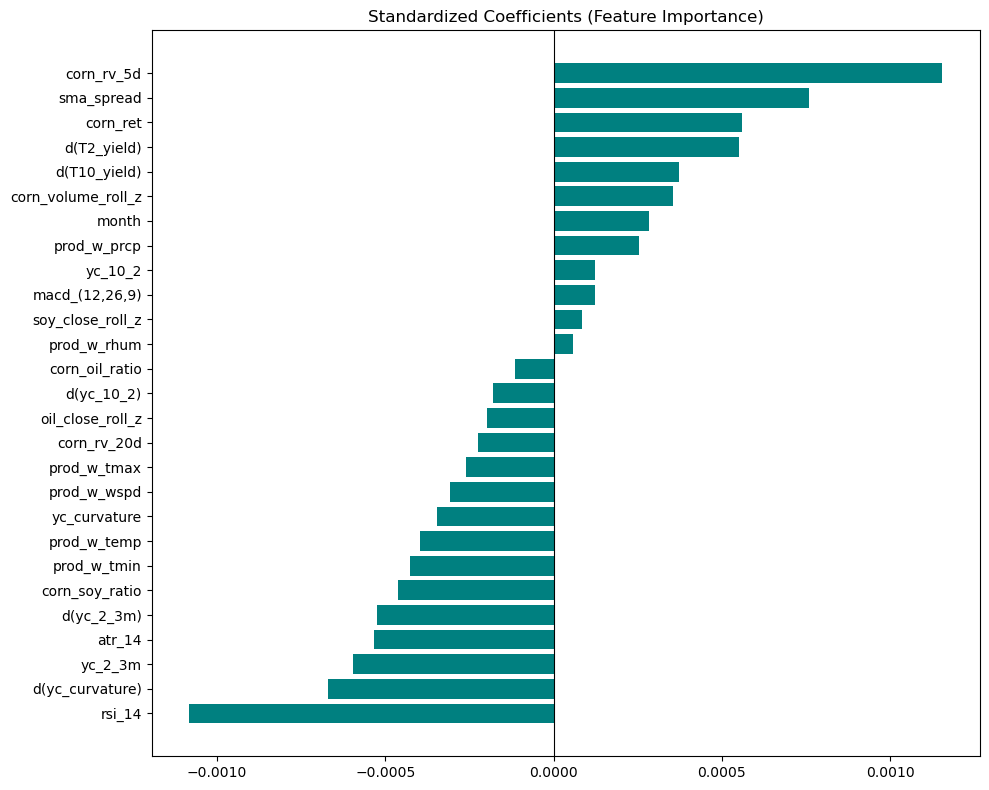

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Load Data
df = pd.read_csv('enriched_corn_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# 2. Define your specific features and target
feature_cols = [
    'corn_ret', 'corn_volume_roll_z','corn_rv_5d', 'corn_rv_20d', 
    'month', 'atr_14', 'sma_spread', 'macd_(12,26,9)', 'rsi_14',
    'oil_close_roll_z', 'soy_close_roll_z', 'corn_soy_ratio', 'corn_oil_ratio',
    'yc_10_2', 'yc_2_3m', 'yc_curvature', 
    'd(yc_10_2)', 'd(yc_2_3m)', 'd(yc_curvature)', 'd(T10_yield)', 'd(T2_yield)',
    'prod_w_temp', 'prod_w_tmin', 'prod_w_tmax', 'prod_w_prcp', 'prod_w_rhum', 'prod_w_wspd'
]
response_col = 'corn_ret_t+1'

# 3. Clean and Split Data (80% Train, 20% Test chronologically)
np.random.seed(42)
df_clean = df[feature_cols + [response_col]].dropna()
X = df_clean[feature_cols]
y = df_clean[response_col]

split_idx = int(len(df_clean) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 4. Feature Scaling (essential for comparing coefficients)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

# 5. Fit the Multiple Linear Regression
X_train_const = sm.add_constant(X_train_scaled) # add intercept
model = sm.OLS(y_train, X_train_const).fit()

# 6. Evaluation and Diagnostics
print(model.summary())

# 7. Check for Multicollinearity (VIF)
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(len(X_train_scaled.columns))]
print("\n--- Variance Inflation Factor (VIF) ---")
print(vif_data.sort_values(by="VIF", ascending=False))

# 8. Visualizing Feature Importance
coef_df = pd.DataFrame({'feature': X_train_scaled.columns, 'coef': model.params[1:]}).sort_values(by='coef')
plt.figure(figsize=(10, 8))
plt.barh(coef_df['feature'], coef_df['coef'], color='teal')
plt.title('Standardized Coefficients (Feature Importance)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()